# MITGCM decorrelation scale and spectral analysis 

**Purpose**: Code for linking the decorrelation scale and power spectrum to explain the causation of the decorrelation scale variability

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean.cm as cmo
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from scipy.stats import chi2
import matplotlib.colors as mcolors

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
from autocorr import compute_autocorr_optimize, compute_decor_scale_optimize, segment_time_series, compute_autocorr_optimize
from spectra import spectrum1D_frequency, spectral_slope, spectral_diagnostics
from lsf import unweighted_lsf, detrend, compute_amp_phase
from var_analysis import variance_scale_analysis_1D

Set data analysis parameters

In [3]:
# Set processing parameters
option_plot          = 0      # Specifies if supplementary plots are plotted
option_var           = 'density'  # Specifies which variable will analyzed. Options include: temp, sal, density, u_along, v_cross
option_bin           = 0

# Set time and space parameters
if option_bin == 0:                          # Specifies the time interval for model run. Units: seconds
    T            = 1*(60)*(60)               # No binning: 1 hour resolution
else:                  
    T            = 12*(60)*(60)              # Binning: 12 hour resolution
estimator    = 'biased'                      # Specifies the approach for estimating the autocorrelation function    
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/temporal/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs_server/mitgcm/scale_analysis/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
fontsize = 16

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Load mitgcm data netcdf files 

In [4]:
#--- MITgcm Data ---# 
if (option_var == 'temp') | (option_var == 'sal') | (option_var == 'density'):
    filename = PATH + "mitgcm_intermediate_data_TSD_hrly_ts_profiles.nc"
elif (option_var == 'u_along') | (option_var == 'v_cross'):
    filename = PATH + "mitgcm_intermediate_data_vel_hrly_ts_profiles.nc"
nc = Dataset(filename, 'r')

# Extract data variables
depth = nc.variables['depth'][:]
lon   = nc.variables['LON'][:]
lat   = nc.variables['LAT'][:]
if option_bin == 1: 
    time  =  num2date(nc.variables['time_bin'][:], nc.variables['time_bin'].units)
else: 
    time  =  num2date(nc.variables['time'][:], nc.variables['time'].units)

if option_var == 'temp':
    data = nc.variables['CTemp'][:]
elif option_var == 'sal':
    data = nc.variables['ASal'][:]
elif option_var == 'density':
    data = nc.variables['SIG'][:]
elif option_var == 'u_along':
    if option_bin == 1: 
        data = nc.variables['u_along_bin'][:]
    else: 
        data = nc.variables['u_along'][:]
elif option_var == 'v_cross':
    if option_bin == 1: 
        data = nc.variables['v_cross_bin'][:]
    else: 
        data = nc.variables['v_cross'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

Plot profile time series and time averaged profile

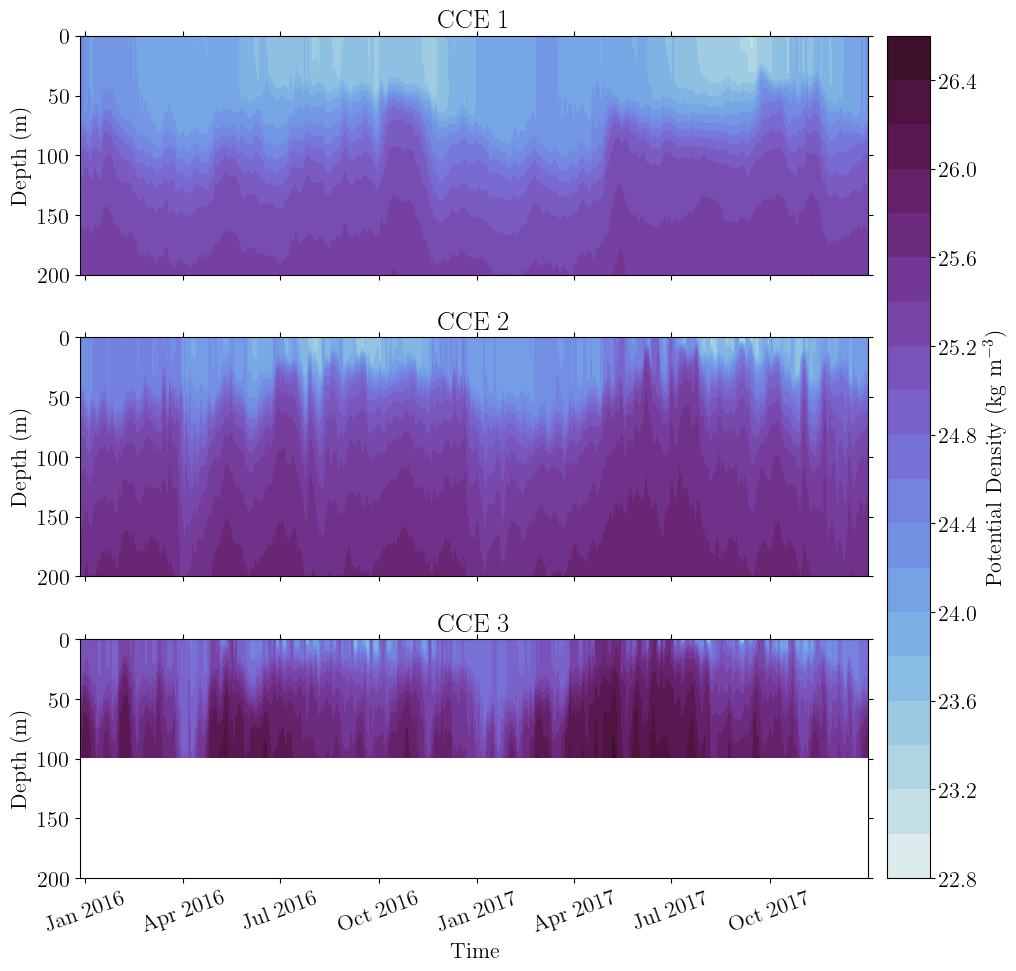

In [5]:
# Set the fontsize
plt.rcParams.update({'font.size': fontsize})

# Set plotting parameters
if option_var == 'temp':
    label = r'Conservative Temperature (deg C)'
    cmap = cmo.thermal
elif option_var == 'sal':
    label = r'Absolute Salinity (g/kg)'
    cmap = cmo.haline
elif option_var == 'density': 
    label = r'Potential Density (kg m$^{-3}$)'
    cmap = cmo.dense
elif option_var == 'u_along': 
    label = r'Along-shelf Velocity (ms$^{-1}$)'
    cmap = cmo.balance
elif option_var == 'v_cross': 
    label = r'Cross-shelf Velocity (ms$^{-1}$)'
    cmap = cmo.balance

# Create figure
fig,axes = plt.subplots(3,1,figsize=(12, 10))
ax1,ax2,ax3 =  axes.flatten()

# Loop through axes
for i, ax in enumerate(axes):

    # Plot temperature
    if (option_var == 'u_along') | (option_var == 'v_cross'): 
        cf = ax.contourf(time_dt,abs(depth),data[i,:,:].T, levels=20, cmap=cmap, vmin=-1.2, vmax=1.2)
    else:
        cf = ax.contourf(time_dt,abs(depth),data[i,:,:].T, levels=20, cmap=cmap)

    # Set axis attributes
    ax.set_title(f"CCE {i+1}")
    ax.set_ylim(0,200)
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.set_ylabel("Depth (m)")
    ax.tick_params(top=True, bottom=True, left=True, right=True,
                   direction='out', length=3.5)
    plt.setp(ax.get_xticklabels(), rotation=20)
    if (i == 0) | (i == 1):
        ax.set_xticklabels([])
    if i == 2:
        ax.set_xlabel("Time")

# Adjust layout before adding colorbar
plt.tight_layout()
fig.subplots_adjust(right=0.87)  # Make space on the right side

# Add shared colorbar
cbar = fig.colorbar(cf, ax=axes, location='right', pad=0.02)
cbar.set_label(label)

# Show figure
plt.show()

Compute the spectral diagnostics and decorrelation scales

In [6]:
# Set dimnesion by segmenting data at a single depth and looking at the lengths
overlap = 0.5                                                                            # Specifies the fractional overlap between segments (e.g., 0.75 for 75% overlap)
segment_years = 1                                                                        # Specifies the length of each segment in years
segments       = segment_time_series(time, data[0,:,0], segment_years=segment_years, overlap=overlap)
nseg,ntime     = np.shape(segments)[0], np.shape(segments)[2]
nsite, _, ndepth = data.shape

# Set windowing parameters
min_window = 100                   # Minimum window length (number of data points, 100 points ~ 4 days)
max_divisor = ntime // min_window  # The largest n such that N/n >= 100

# Generate divisors (fractions of the total length): 2, 3, 4, ..., max_divisor
divisors = np.arange(2, max_divisor + 1)

# Calculate window sizes directly using integer division (//) to ensure they are integers
window_sizes = ntime // divisors

# Filter for range (if necessary) 
window_sizes = window_sizes[window_sizes >= min_window]

# Remove duplicates
window_sizes = np.unique(window_sizes)[::-1]  # Unique and sorted largest to smallest
n_windows = len(window_sizes)  # Number of window lengths

# Find the indices of the upper 200 meter depths
depth_indices = np.where(depth >= -250)[0]

# Set the number of depths to iterate over for the top 200 meters
ndepth_upper = depth_indices[-1]
depth_upper = depth[0:ndepth_upper]

# Set parameters
w1, w2 = [(2*np.pi)/31557600, (2)*(2*np.pi)/31557600]        # Specifies the radian Frequency for annual and semi-annual cycles. Units: rad/sec
M = 10                                                       # Specifies number of windows to divide the data into for the Welch method
p = ntime // M                                               # Specifies window length, i.e., number of data points in each segment
nfft = (p // 2 + 1) if (p % 2 == 0) else ((p - 1) // 2)      # Specifies number of positive frequency bins in the resulting power spectrum
units = 'Hz'                                                 # Specifies the units of the frequency vector 
estimator = 'biased'                                         # Specifies the type of autocorrelation estimator ('biased' or 'unbiased')
T_days = T*(1/60)*(1/60)*(1/24)
option_plot = False

# Define frequency range for slope fitting 
fmin_sub = 3*10**(-2) 
fmax_sub = 8*10**(-1) 
fmin_sup = 1 
fmax_sup = 12
    
# Compute the elapsed time from beginning of segmented time series (units: seconds)
t0 = time[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time])

# Initialize arrays
Lt_seg      = np.zeros((nsite,ndepth_upper))
Lt_seg_stdm = np.zeros((nsite,ndepth_upper))
S_seg       = np.zeros((nsite,ndepth_upper,nfft))
CI_seg      = np.zeros((nsite,ndepth_upper,nfft,2))
rms_seg     = np.zeros((nsite,ndepth_upper))
fve_seg     = np.zeros((nsite,ndepth_upper))
var_total   = np.zeros((nsite,ndepth_upper))
var_anomaly = np.zeros((nsite,ndepth_upper))
var_total_unc   = np.zeros((nsite,ndepth_upper))
var_anomaly_unc = np.zeros((nsite,ndepth_upper))
var_con         = np.zeros((nsite,ndepth_upper,2))
S_seg_slope_sub     = np.zeros((nsite,ndepth_upper))
S_seg_slope_sub_unc = np.zeros((nsite,ndepth_upper))
S_seg_slope_sup     = np.zeros((nsite,ndepth_upper))
S_seg_slope_sup_unc = np.zeros((nsite,ndepth_upper))
S_seg_moments       = np.zeros((nsite,ndepth_upper,4))
S_seg_nu            = np.zeros((nsite,ndepth_upper))
S_seg_skew          = np.zeros((nsite,ndepth_upper))
S_seg_entropy       = np.zeros((nsite,ndepth_upper))
S_seg_fve           = np.zeros((nsite,ndepth_upper,2))
S_seg_period        = np.zeros((nsite,ndepth_upper))
L_seg               = np.zeros((nsite,ndepth_upper,n_windows))
V_seg               = np.zeros((nsite,ndepth_upper,n_windows))
p_seg               = np.zeros((nsite,ndepth_upper))
p_seg_unc           = np.zeros((nsite,ndepth_upper))

# Loop over each site
for isite in range(nsite):

    # Print site progress
    print(f"\nProcessing site {isite+1} of {nsite}")
    
    # Loop over each depth
    for idepth in range(0,ndepth_upper):

        # Set progress bar
        progress = (idepth) / (ndepth_upper)
        sys.stdout.write(f"\rProgress: {progress:.1%}")
        sys.stdout.flush()
        
        # Extract full time series at this site and depth
        data_ts = data[isite, :, idepth]

        # Skip depth if all values are masked
        if np.all(data_ts.mask):
            continue

        # Remove seasonal cycle
        hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters=2, freqs=np.array([w1, w2]), sigma=None)
        
        # Compute the fraction of variance explained and residual
        data_prime, rms_seg[isite,idepth], fve_seg[isite,idepth], _, _ = compute_amp_phase(data_ts, hfit, x_data, parameters = 2)

        # Segment both total and anomalous time series 
        segments       = segment_time_series(time_dt, data_ts, segment_years=segment_years, overlap=overlap)
        segments_prime = segment_time_series(time_dt, data_prime, segment_years=segment_years, overlap=overlap)

        # Initialize arrays
        autocorr_seg   = np.full((nseg,ntime), np.nan)
        time_scale_seg = np.full((nseg,ntime), np.nan)
        S_seg_tmp      = np.full((nseg,nfft), np.nan)
        CI_seg_tmp     = np.zeros((nseg,nfft,2))
        var_seg_con    = np.zeros((nseg,2))
        var_seg_tot    = np.zeros((nseg,1))
        var_seg_anom   = np.zeros((nseg,1))
        stdv_seg_tot   = np.zeros((nseg,1))
        stdv_seg_anom  = np.zeros((nseg,1))
        L_seg_tmp      = np.full((nseg,n_windows), np.nan)
        V_seg_tmp      = np.full((nseg,n_windows), np.nan)

        # ------------------------------------------------------------------
        # Raw time series 
        # ------------------------------------------------------------------

        # Loop through raw data segments
        for i, (tseg, dseg) in enumerate(segments):

            # Compute the elapsed time from beginning of segmented time series (units: seconds)
            t0 = tseg[0]
            time_elapsed_seg = np.array([(t - t0).total_seconds() for t in tseg])
            
            # Detrend data record 
            data_dt = detrend(dseg, time_elapsed_seg, mean = 0)

            # Compute autocorrelation function
            lag = len(time_elapsed_seg)
            autocorr_tmp, _, _, _, time_lag_tmp, _ = compute_autocorr_optimize(data_dt, time_elapsed_seg, lag, estimator, 0)

            # Compute the decorrelation scale and the number of independent samples 
            Lt_tmp = compute_decor_scale_optimize(autocorr_tmp,time_lag_tmp,T,'unbiased',0)
            Lt_tmp_days = Lt_tmp * (1/60) * (1/60) * (1/24)
            
            # Compute the number of independent samples
            n_d = Lt_tmp_days/T_days
            Neff = len(dseg)/n_d

            # Compute the variance and the standard error of the variance of the ith segment 
            var_seg_tot[i] = np.var(dseg, ddof=1) 
            stdv_seg_tot[i] = var_seg_tot[i]*np.sqrt(2/(Neff - 1))

            # Save the autocorrelation and compute spectra if data are a velocity component
            if option_var in ('u_along', 'v_cross'):

                # Save autocorrelation function and time lag 
                autocorr_seg[i,:]   = autocorr_tmp 
                time_scale_seg[i,:] = time_lag_tmp

                # Compute frequency power spectrum 
                data_interp = np.interp(time_elapsed_seg, time_elapsed_seg[~data_dt.mask], data_dt[~data_dt.mask])
                S_seg_tmp[i,:], f_seg, CI_seg_tmp[i,:,:], var_seg_con[i,:] = spectrum1D_frequency(data_interp, T, M, units)

        # ------------------------------------------------------------------
        # Anomaly time series 
        # ------------------------------------------------------------------

        # Loop through anomaly segments
        for i, (tseg, dseg) in enumerate(segments_prime):

            # Compute the elapsed time from beginning of segmented time series (units: seconds)
            t0 = tseg[0]
            time_elapsed_seg = np.array([(t - t0).total_seconds() for t in tseg])
            
            # Detrend data record 
            data_dt = detrend(dseg, time_elapsed_seg, mean = 0)

            # Compute autocorrelation function
            lag = len(time_elapsed_seg)
            autocorr_tmp, _, _, _, time_lag_tmp, _ = compute_autocorr_optimize(data_dt, time_elapsed_seg, lag, estimator, 0)

            # Compute the decorrelation scale and the number of independent samples 
            Lt_tmp = compute_decor_scale_optimize(autocorr_tmp,time_lag_tmp,T,'unbiased',0)
            Lt_tmp_days = Lt_tmp * (1/60) * (1/60) * (1/24)
            
            # Compute the number of independent samples
            n_d = Lt_tmp_days/T_days
            Neff = len(dseg)/n_d

            # Compute the variance of the ith segment 
            var_seg_anom[i] = np.var(dseg, ddof=1) 
            stdv_seg_anom[i] = var_seg_anom[i]*np.sqrt(2/(Neff - 1))

            # Compute scale variance and patchiness
            L_seg_tmp[i,:], V_seg_tmp[i,:], _, _ = variance_scale_analysis_1D(data_dt, scales=window_sizes, fit_range=None, overlap=0.05, return_windows=False)

            # Save the autocorrelation and compute spectra if data are a temperature, salinity, or density
            if option_var in ('temp', 'sal', 'density'):

                # Save autocorrelation function and time lag 
                autocorr_seg[i,:]   = autocorr_tmp 
                time_scale_seg[i,:] = time_lag_tmp

                # Compute frequency power spectrum 
                data_interp = np.interp(time_elapsed_seg, time_elapsed_seg[~data_dt.mask], data_dt[~data_dt.mask])
                S_seg_tmp[i,:], f_seg, CI_seg_tmp[i,:,:], var_seg_con[i,:] = spectrum1D_frequency(data_interp, T, M, units)

        # Compute the mean variance between segments and its uncertainty 
        var_total[isite,idepth]       = np.mean(var_seg_tot)
        var_anomaly[isite,idepth]     = np.mean(var_seg_anom)
        var_total_unc[isite,idepth]   = np.sqrt(np.sum(stdv_seg_tot**2))/nseg
        var_anomaly_unc[isite,idepth] = np.sqrt(np.sum(stdv_seg_anom**2))/nseg
        var_con[isite,idepth,:]       = np.mean(var_seg_con,axis=0)

        # Compute the mean frequency spectrum and convert to cycles per day
        S_seg[isite,idepth,:] = np.nanmean(S_seg_tmp, axis=0)/(60 * 60 * 24)

        # Compute the mean scale variance 
        L_seg[isite,idepth,:] = np.nanmean(L_seg_tmp, axis=0)
        V_seg[isite,idepth,:] = np.nanmean(V_seg_tmp, axis=0)

        # Log-transform for power-law relationship
        logL, logV = np.log10(L_seg[isite,idepth,:]), np.log10(V_seg[isite,idepth,:])  

        # Preform least squares fit (linear regression in log-log space)
        A = np.vstack([np.ones_like(logL), logL]).T
        coef, *_ = np.linalg.lstsq(A, logV, rcond=None)

        # Grab slope estimate
        p_seg[isite,idepth] = coef[1]

        # Compute unweighted least square fit model and map fit back to linear space
        V_fit_log = A @ coef
        V_fit = 10**V_fit_log

        # Compute uncertainty in p
        M_tmp = len(logV)
        parameters = 2

        # Compute variance uncertainty of data in 
        var_fit = np.sum((logV - V_fit_log)**2) / (M_tmp - parameters)
        std_fit = np.sqrt(var_fit)

        # Compute standard error of the spectral slope
        delta = M_tmp * np.sum(logL**2) - (np.sum(logL))**2
        p_seg_unc[isite,idepth] = std_fit * np.sqrt(M_tmp / delta)

        # Set significance level and effective degrees of freedom 
        alpha      = 0.05                         # Significance level
        nu         = (36 / 19) * (2 * ntime - 1)  # Number of degrees of freedom for each spectral estimate
        nu_eff     = 2 * nu                       # Number of effective degrees of freedom for the average spectrum with 50% overlap between the window (if full independent: nu_eff = 3*nu, if full dependent (rho = 1): nu_eff = nu. So the 50% case lies inbetween). 
        
        # Compute the upper and lower bounds of confidence interval
        error_high = nu_eff / chi2.ppf(alpha / 2, nu_eff)    
        error_low  = nu_eff / chi2.ppf(1 - alpha / 2, nu_eff)

        # Compute the 95% confidence level for the average spectrum
        CI_seg[isite,idepth,:,:] = np.column_stack((error_low * S_seg[isite,idepth,:], error_high * S_seg[isite,idepth,:]))

        # Compute the sub-inertial and super inertial spectral slope
        f_cpd_seg = f_seg*(60)*(60)*(24)
        S_seg_slope_sub[isite,idepth], S_seg_slope_sub_unc[isite,idepth], S_fit_sub, f_range_sub = spectral_slope(f_cpd_seg, S_seg[isite,idepth,:], fmin_sub, fmax_sub)
        S_seg_slope_sup[isite,idepth], S_seg_slope_sup_unc[isite,idepth], S_fit_sup, f_range_sup = spectral_slope(f_cpd_seg, S_seg[isite,idepth,:], fmin_sup, fmax_sup)

        # Compute Spectral Diagnostics
        f_cutoff = 0.7                   # Units: cpd
        S_seg_moments[isite,idepth,:], S_seg_nu[isite,idepth], S_seg_skew[isite,idepth], S_seg_entropy[isite,idepth], S_seg_fve[isite,idepth,:], S_seg_period[isite,idepth] = spectral_diagnostics(S_seg[isite,idepth,:], f_cpd_seg, f_cutoff)

        # Plot Spectral slope 
        if option_plot == True: 
                
                plt.figure(figsize=(8, 5))
                plt.loglog(f_cpd_seg[1:], S_seg[isite,idepth,1:], label='PSD')
                plt.loglog(f_range_sub, S_fit_sub, '--r', label=f'Fit: slope = {S_seg_slope_sub[isite,idepth]:.2f} ± {S_seg_slope_sub_unc[isite,idepth]:.2f}')
                plt.loglog(f_range_sup, S_fit_sup, '--r', label=f'Fit: slope = {S_seg_slope_sup[isite,idepth]:.2f} ± {S_seg_slope_sup_unc[isite,idepth]:.2f}')
                plt.xlabel('Frequency [Hz]')
                plt.ylabel('PSD')
                plt.title('Spectral Slope Test')
                plt.legend()
                plt.grid(True, which='both', ls='--')
                plt.tight_layout()
                plt.show()

        # Plot Scale variance slope 
        if option_plot == True: 
                
                plt.figure(figsize=(8, 5))
                plt.loglog(L_seg[isite,idepth,1:]/24, V_seg[isite,idepth,1:], '.-', label='Scaled Variance')
                plt.loglog(L_seg[isite,idepth,1:]/24, V_fit[1:], '--r', label=f'Fit: slope = {p_seg[isite,idepth]:.2f} ± {p_seg_unc[isite,idepth]:.2f}')
                plt.xlabel('Scale (days)')
                plt.ylabel('Normalized Variance V')
                plt.title('Scale Variance Slope Test')
                plt.legend()
                plt.grid(True, which='both', ls='--')
                plt.tight_layout()
                plt.show()

        # Compute the mean autocorrelation function 
        meanAutocorr = np.nanmean(autocorr_seg, axis=0)

        # Compute the standard deviation and the number of samples 
        stdAutocorr = np.nanstd(autocorr_seg, axis=0, ddof=1)
        nAutocorr   = np.count_nonzero(~np.isnan(autocorr_seg), axis=0)

        # Compute the standard error of the mean (assuming that each data point is an independent observations)
        stdmAutocorr   = stdAutocorr/np.sqrt(nAutocorr)

        # Compute the decorrelation scale 
        Lt_seg[isite,idepth]  = compute_decor_scale_optimize(meanAutocorr,time_scale_seg[0,:],T,'unbiased',0)

        # Estimate the decorrelation scale's uncertainty by perturbing the autocorrelation function by 1 standard deviation
        Lt_ustd = compute_decor_scale_optimize(meanAutocorr + stdmAutocorr ,time_scale_seg[0,:] ,T,'unbiased',0)
        Lt_lstd = compute_decor_scale_optimize(meanAutocorr - stdmAutocorr ,time_scale_seg[0,:] ,T,'unbiased',0)

        # Compute the average standard error 
        std_upper = Lt_ustd - Lt_seg[isite,idepth]
        std_lower = abs(Lt_lstd - Lt_seg[isite,idepth])
        Lt_seg_stdm[isite,idepth]  = np.mean([std_upper, std_lower])

# Convert to days
Lt_seg_days      = Lt_seg*(1/60)*(1/60)*(1/24)
Lt_seg_stdm_days = Lt_seg_stdm*(1/60)*(1/60)*(1/24)
f_cpd_seg        = f_seg*(60*60*24)

# Mask zero values 
Lt_seg_days      = np.ma.masked_equal(Lt_seg_days, 0)
Lt_seg_stdm_days = np.ma.masked_equal(Lt_seg_stdm_days, 0)
p_seg            = np.ma.masked_equal(p_seg, 0)
p_seg_unc        = np.ma.masked_equal(p_seg_unc, 0)
S_seg_moments    = np.ma.masked_equal(S_seg_moments, 0)
S_seg_nu         = np.ma.masked_equal(S_seg_nu, 0)
S_seg_skew       = np.ma.masked_equal(S_seg_skew, 0)
S_seg_entropy    = np.ma.masked_equal(S_seg_entropy, 0)
S_seg_fve        = np.ma.masked_equal(S_seg_fve, 0)
S_seg_period     = np.ma.masked_equal(S_seg_period, 0)



Processing site 1 of 3
Progress: 96.6%
Processing site 2 of 3
Progress: 96.6%
Processing site 3 of 3
Progress: 96.6%

Plot decorrelation scale with error bars 

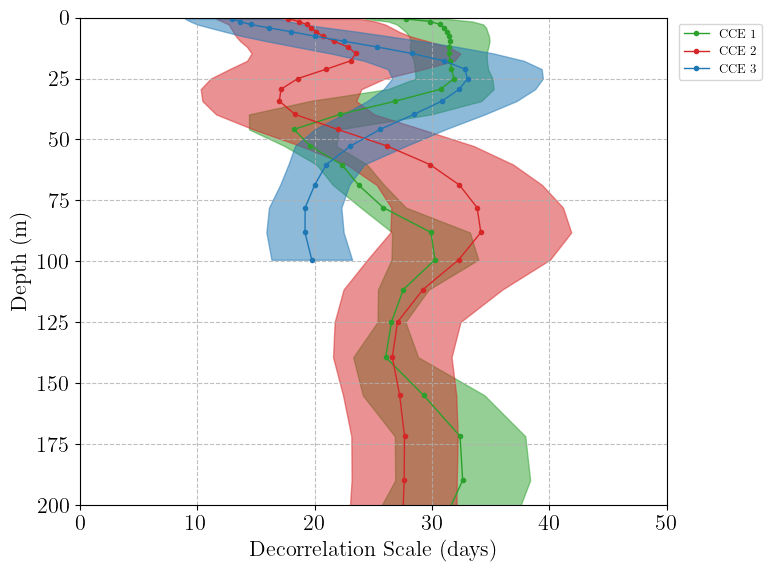

In [7]:
# Create the figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# Plot the depth-dependent decorrelation time scale
ax.plot(Lt_seg_days[0,:], abs(depth_upper), '.-', color='tab:green', linewidth=1,label='CCE 1')
ax.plot(Lt_seg_days[1,:], abs(depth_upper), '.-', color='tab:red', linewidth=1, label='CCE 2')
ax.plot(Lt_seg_days[2,:], abs(depth_upper), '.-', color='tab:blue', linewidth=1, label='CCE 3')

# Plot standard error of the mean profiles for each mooring
ax.fill_betweenx(abs(depth_upper), Lt_seg_days[0,:] - Lt_seg_stdm_days[0,:], Lt_seg_days[0,:] + Lt_seg_stdm_days[0,:], color='tab:green', alpha=0.5)
ax.fill_betweenx(abs(depth_upper), Lt_seg_days[1,:] - Lt_seg_stdm_days[1,:], Lt_seg_days[1,:] + Lt_seg_stdm_days[1,:], color='tab:red', alpha=0.5)
ax.fill_betweenx(abs(depth_upper), Lt_seg_days[2,:] - Lt_seg_stdm_days[2,:], Lt_seg_days[2,:] + Lt_seg_stdm_days[2,:], color='tab:blue', alpha=0.5)

# Set figure attributes
ax.set_xlabel(r'Decorrelation Scale (days)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,50)
ax.set_ylim(0,200)
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Reverse the direction of the x-axis 
ax.invert_yaxis() 

# Display figure
plt.tight_layout()
plt.show()

Plot a single Mooring Diagnostic Profile 

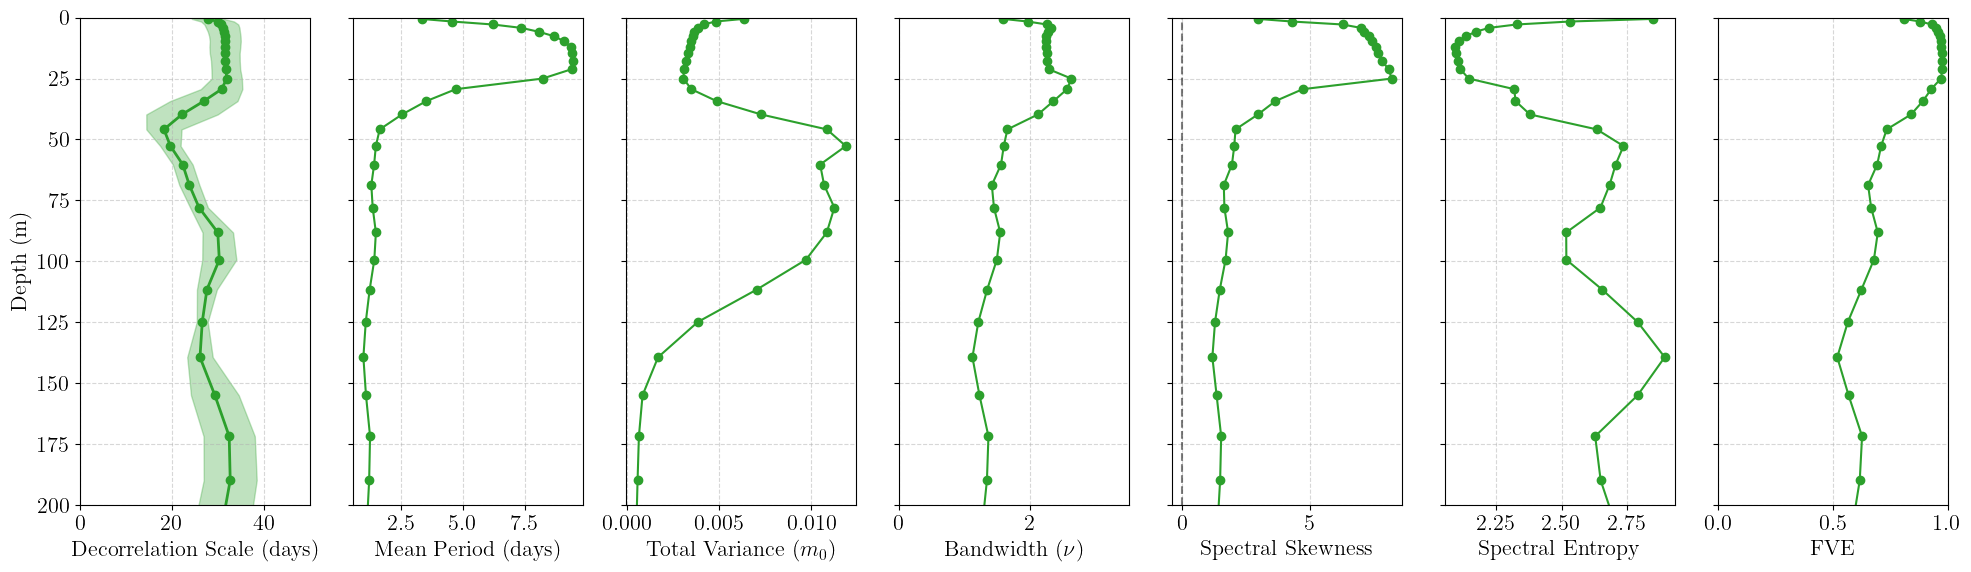

In [9]:
# Assuming data for CCE 1 (index 0)
mooring_idx = 0
mooring_name = 'CCE 1'
color = 'tab:green'

fig, axes = plt.subplots(1, 7, figsize=(20, 6), sharey=True)

# 1. Decorrelation Scale (The "Physical" result)
axes[0].plot(Lt_seg_days[mooring_idx,:], abs(depth_upper), 'o-', color=color, linewidth=2)
axes[0].fill_betweenx(abs(depth_upper), 
                     Lt_seg_days[mooring_idx,:] - Lt_seg_stdm_days[mooring_idx,:], 
                     Lt_seg_days[mooring_idx,:] + Lt_seg_stdm_days[mooring_idx,:], 
                     color=color, alpha=0.3)
axes[0].set_xlabel('Decorrelation Scale (days)')
axes[0].set_ylabel('Depth (m)')
axes[0].set_xlim(0, 50)

# 2. Mean Period
axes[1].plot(S_seg_period[mooring_idx,:] , abs(depth_upper), 'o-', color=color)
axes[1].set_xlabel(r'Mean Period (days)')
#axes[1].set_xlim(0, 50)

# 2. Total Variance (m0)
axes[2].plot(S_seg_moments[mooring_idx,:,0], abs(depth_upper), 'o-', color=color)
axes[2].set_xlabel(r'Total Variance ($m_0$)')
#axes[2].set_xscale('log') # Usually helpful for energy profiles

# 3. Spectral Bandwidth (nu)
axes[3].plot(S_seg_nu[mooring_idx,:], abs(depth_upper), 'o-', color=color)
axes[3].set_xlabel(r'Bandwidth ($\nu$)')
axes[3].set_xlim(0, 3.5)

# 4. Spectral Skewness (gamma)
axes[4].plot(S_seg_skew[mooring_idx,:], abs(depth_upper), 'o-', color=color)
axes[4].set_xlabel('Spectral Skewness')
axes[4].axvline(0, color='k', linestyle='--', alpha=0.5)

# 5. Spectral Entropy
axes[5].plot(S_seg_entropy[mooring_idx,:], abs(depth_upper), 'o-', color=color)
axes[5].set_xlabel('Spectral Entropy')

# 5. Meso/Tidal Energy FVE 
axes[6].plot(S_seg_fve[mooring_idx,:,0], abs(depth_upper), 'o-', color=color)
#axes[6].plot(S_seg_fve[mooring_idx,:,1], abs(depth_upper), 'o--', color=color)
axes[6].set_xlabel('FVE')
axes[6].set_xlim(0, 1)

# Formatting for all axes
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.invert_yaxis() # Depth increases downwards
    ax.set_ylim(200, 0)

plt.tight_layout()
plt.show()

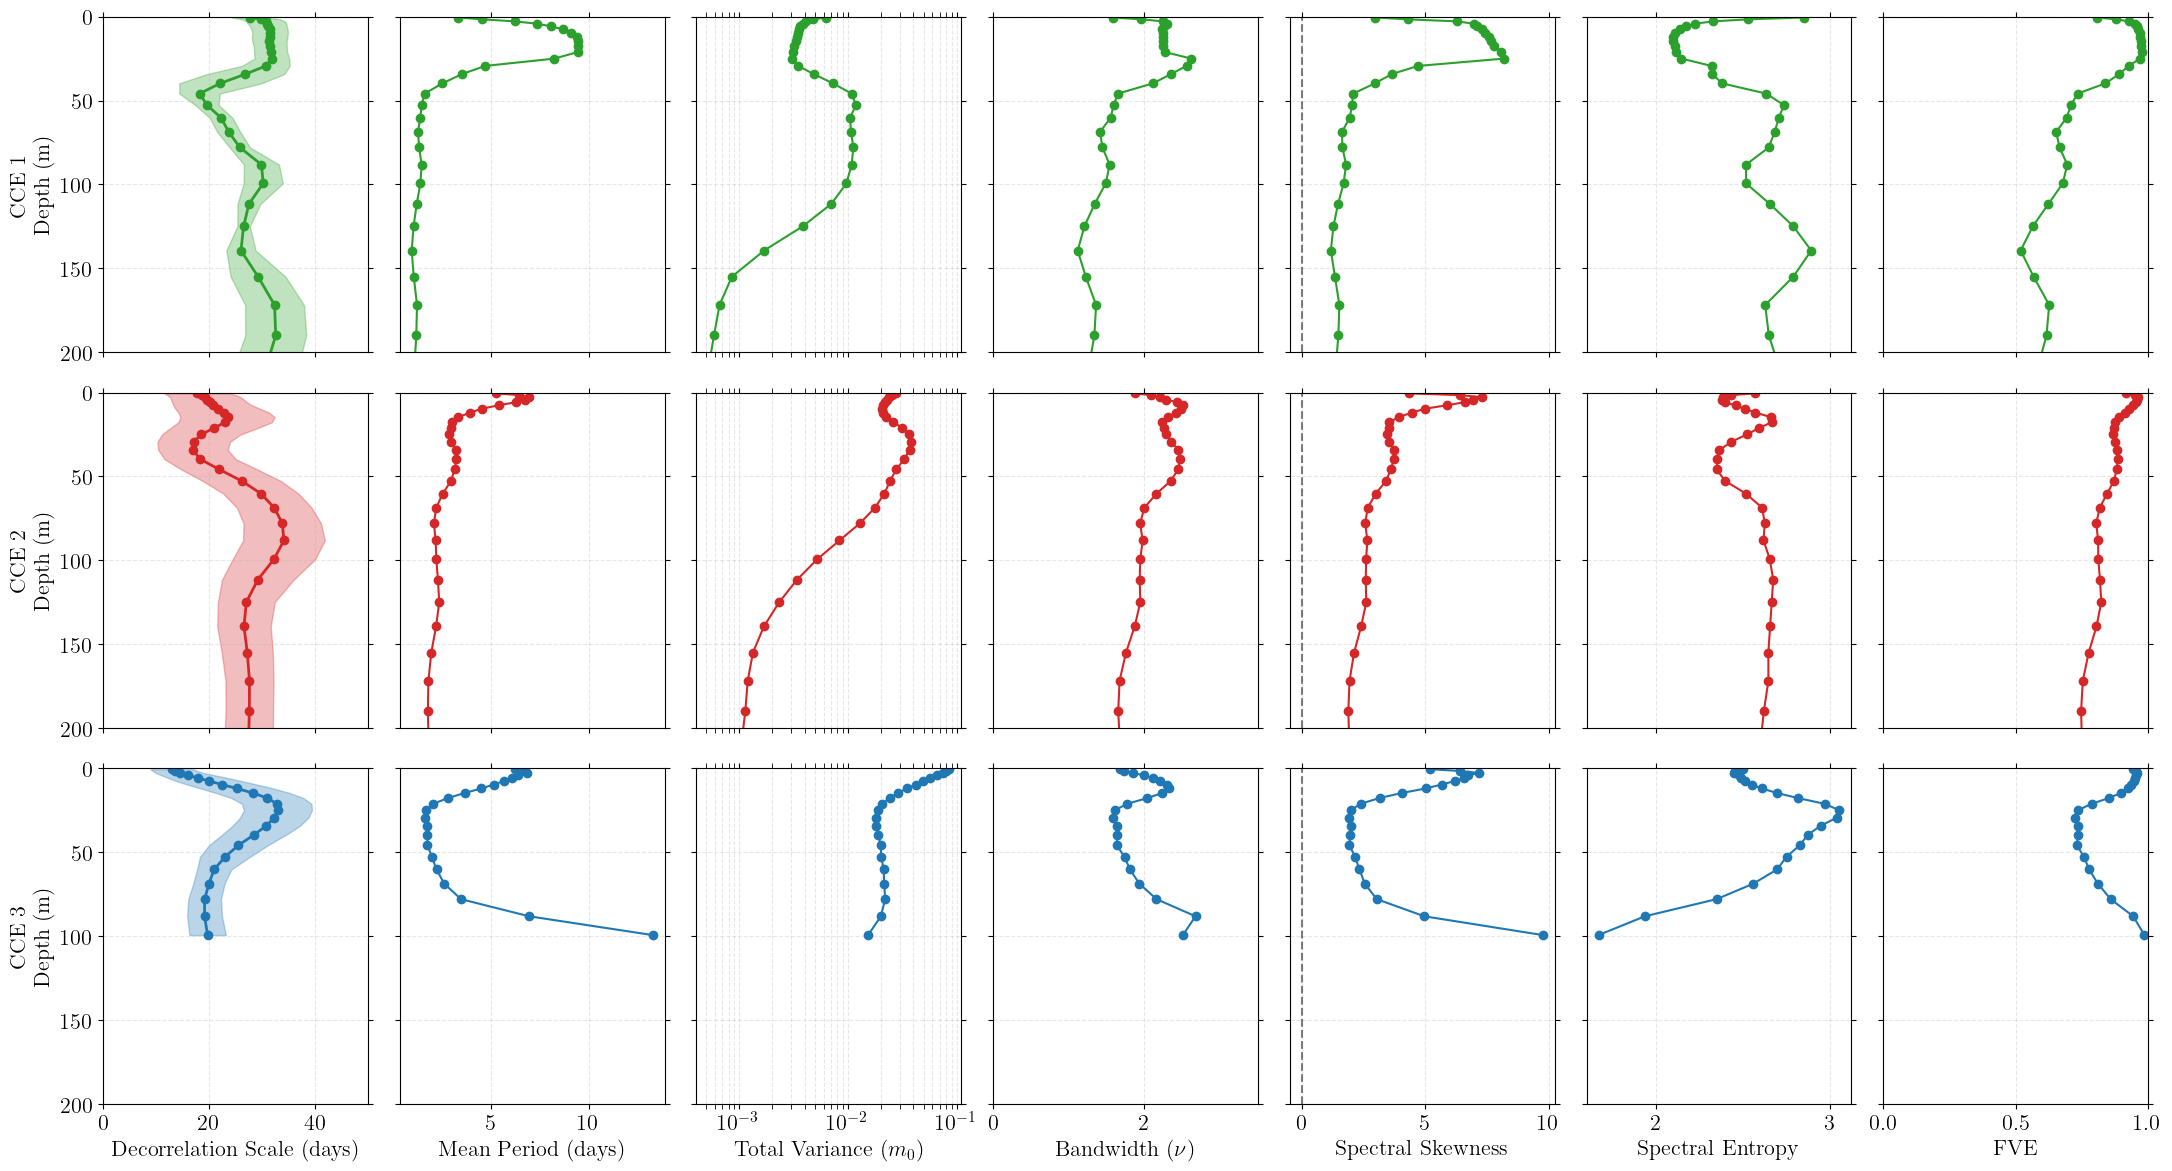

In [11]:
# Configuration for the three sites
mooring_names = ['CCE 1', 'CCE 2', 'CCE 3']
colors = ['tab:green', 'tab:red', 'tab:blue']

# 3 rows (sites), 7 columns (metrics)
fig, axes = plt.subplots(3, 7, figsize=(22, 12), sharey=True, sharex='col')

for row_idx, mooring_name in enumerate(mooring_names):
    color = colors[row_idx]
    
    # 1. Decorrelation Scale
    axes[row_idx, 0].plot(Lt_seg_days[row_idx,:], abs(depth_upper), 'o-', color=color, linewidth=2)
    axes[row_idx, 0].fill_betweenx(abs(depth_upper), 
                         Lt_seg_days[row_idx,:] - Lt_seg_stdm_days[row_idx,:], 
                         Lt_seg_days[row_idx,:] + Lt_seg_stdm_days[row_idx,:], 
                         color=color, alpha=0.3)
    axes[row_idx, 0].set_xlim(0, 50)
    if row_idx == 2: axes[row_idx, 0].set_xlabel('Decorrelation Scale (days)')
    axes[row_idx, 0].set_ylabel(f'{mooring_name}\nDepth (m)')

    # 2. Mean Period
    axes[row_idx, 1].plot(S_seg_period[row_idx,:] , abs(depth_upper), 'o-', color=color)
    if row_idx == 2: axes[row_idx, 1].set_xlabel('Mean Period (days)')

    # 3. Total Variance (m0) - LOG SCALE
    axes[row_idx, 2].plot(S_seg_moments[row_idx,:,0], abs(depth_upper), 'o-', color=color)
    axes[row_idx, 2].set_xscale('log') 
    if row_idx == 2: axes[row_idx, 2].set_xlabel(r'Total Variance ($m_0$)')

    # 4. Spectral Bandwidth (nu)
    axes[row_idx, 3].plot(S_seg_nu[row_idx,:], abs(depth_upper), 'o-', color=color)
    axes[row_idx, 3].set_xlim(0, 3.5)
    if row_idx == 2: axes[row_idx, 3].set_xlabel(r'Bandwidth ($\nu$)')

    # 5. Spectral Skewness (gamma)
    axes[row_idx, 4].plot(S_seg_skew[row_idx,:], abs(depth_upper), 'o-', color=color)
    axes[row_idx, 4].axvline(0, color='k', linestyle='--', alpha=0.5)
    if row_idx == 2: axes[row_idx, 4].set_xlabel('Spectral Skewness')

    # 6. Spectral Entropy
    axes[row_idx, 5].plot(S_seg_entropy[row_idx,:], abs(depth_upper), 'o-', color=color)
    if row_idx == 2: axes[row_idx, 5].set_xlabel('Spectral Entropy')

    # 7. Meso/Tidal Energy Ratio
    axes[row_idx, 6].plot(S_seg_fve[row_idx,:,0], abs(depth_upper), 'o-', color=color)
    axes[row_idx, 6].set_xlim(0, 1)
    if row_idx == 2: axes[row_idx, 6].set_xlabel('FVE')

# Global formatting for all 21 axes
for ax in axes.flat:
    ax.grid(True, which='both', linestyle='--', alpha=0.3) # 'both' grid for log scale minor lines
    ax.invert_yaxis() 
    ax.set_ylim(200, 0)
    
    # Tick marks on all sides, pointing inward, without labels on top/right
    ax.tick_params(axis='both', which='both', direction='out', 
                   top=True, right=True, 
                   labeltop=False, labelright=False, length=3.5)

plt.tight_layout()
plt.subplots_adjust(hspace=0.12, wspace=0.12)
plt.show()

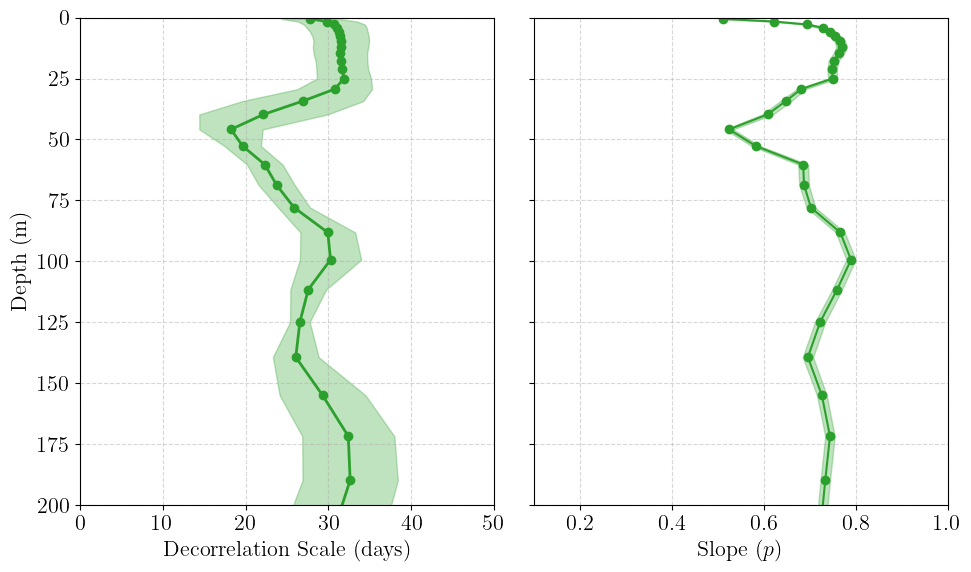

In [25]:
# Assuming data for CCE 1 (index 0)
mooring_idx = 0
mooring_name = 'CCE 1'
color = 'tab:green'

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

# 1. Decorrelation Scale (The "Physical" result)
axes[0].plot(Lt_seg_days[mooring_idx,:], abs(depth_upper), 'o-', color=color, linewidth=2)
axes[0].fill_betweenx(abs(depth_upper), 
                     Lt_seg_days[mooring_idx,:] - Lt_seg_stdm_days[mooring_idx,:], 
                     Lt_seg_days[mooring_idx,:] + Lt_seg_stdm_days[mooring_idx,:], 
                     color=color, alpha=0.3)
axes[0].set_xlabel('Decorrelation Scale (days)')
axes[0].set_ylabel('Depth (m)')
axes[0].set_xlim(0, 50)

# 2. Slope of Scaled Variance (m0)
axes[1].plot(p_seg[mooring_idx,:], abs(depth_upper), 'o-', color=color)
axes[1].fill_betweenx(abs(depth_upper), 
                     p_seg[mooring_idx,:] - p_seg_unc[mooring_idx,:], 
                     p_seg[mooring_idx,:] + p_seg_unc[mooring_idx,:], 
                     color=color, alpha=0.3)
axes[1].set_xlabel(r'Slope ($p$)')
axes[1].set_xlim(0.1, 1)

# Formatting for all axes
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.invert_yaxis() # Depth increases downwards
    ax.set_ylim(200, 0)

plt.tight_layout()
plt.show()

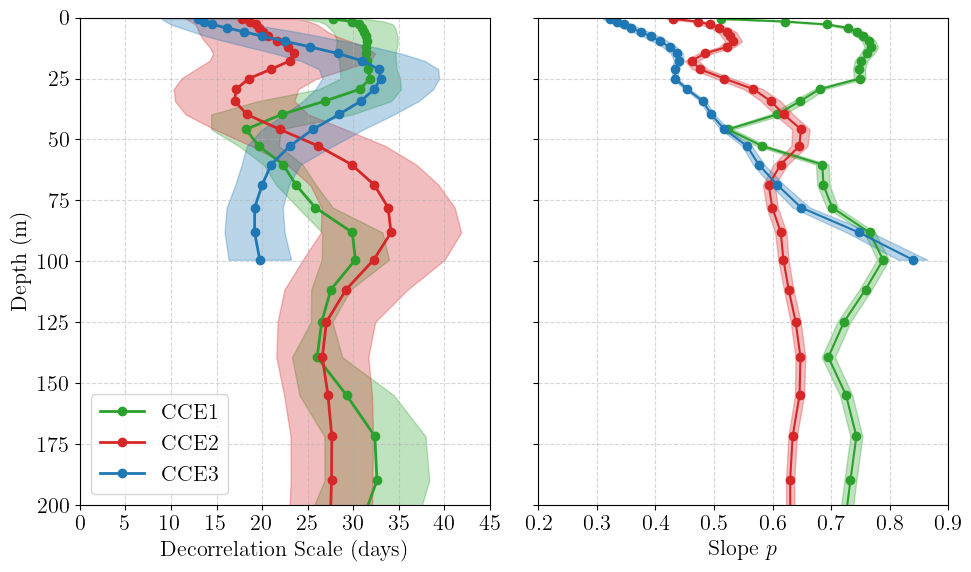

In [50]:
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

# 1. Decorrelation Scale (The "Physical" result)
axes[0].plot(Lt_seg_days[0,:], abs(depth_upper), 'o-', color='tab:green', linewidth=2, label='CCE1')
axes[0].plot(Lt_seg_days[1,:], abs(depth_upper), 'o-', color='tab:red', linewidth=2, label='CCE2')
axes[0].plot(Lt_seg_days[2,:], abs(depth_upper), 'o-', color='tab:blue', linewidth=2, label='CCE3')
axes[0].fill_betweenx(abs(depth_upper), Lt_seg_days[0,:] - Lt_seg_stdm_days[0,:], Lt_seg_days[0,:] + Lt_seg_stdm_days[0,:], color='tab:green', alpha=0.3)
axes[0].fill_betweenx(abs(depth_upper), Lt_seg_days[1,:] - Lt_seg_stdm_days[1,:], Lt_seg_days[1,:] + Lt_seg_stdm_days[1,:], color='tab:red', alpha=0.3)
axes[0].fill_betweenx(abs(depth_upper), Lt_seg_days[2,:] - Lt_seg_stdm_days[2,:], Lt_seg_days[2,:] + Lt_seg_stdm_days[2,:], color='tab:blue', alpha=0.3)
axes[0].set_xlabel('Decorrelation Scale (days)')
axes[0].set_ylabel('Depth (m)')
axes[0].set_xlim(0, 45)
axes[0].legend()
axes[0].set_xticks(np.arange(0,45+5,5))
axes[0].set_yticks(np.arange(0,200+25,25))

# 2. Slope of Scaled Variance (m0)
axes[1].plot(p_seg[0,:], abs(depth_upper), 'o-', color='tab:green')
axes[1].plot(p_seg[1,:], abs(depth_upper), 'o-', color='tab:red')
axes[1].plot(p_seg[2,:], abs(depth_upper), 'o-', color='tab:blue')
axes[1].fill_betweenx(abs(depth_upper), p_seg[0,:] - p_seg_unc[0,:], p_seg[0,:] + p_seg_unc[0,:], color='tab:green', alpha=0.3)
axes[1].fill_betweenx(abs(depth_upper), p_seg[1,:] - p_seg_unc[1,:], p_seg[1,:] + p_seg_unc[1,:], color='tab:red', alpha=0.3)
axes[1].fill_betweenx(abs(depth_upper), p_seg[2,:] - p_seg_unc[2,:], p_seg[2,:] + p_seg_unc[2,:], color='tab:blue', alpha=0.3)
axes[1].set_xlabel(r'Slope $p$')
axes[1].set_xlim(0.2, 0.9)
axes[1].set_xticks(np.arange(0.2,0.9+0.1,0.1))

# Formatting for all axes
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.invert_yaxis() # Depth increases downwards
    ax.set_ylim(200, 0)

plt.tight_layout()
plt.show()

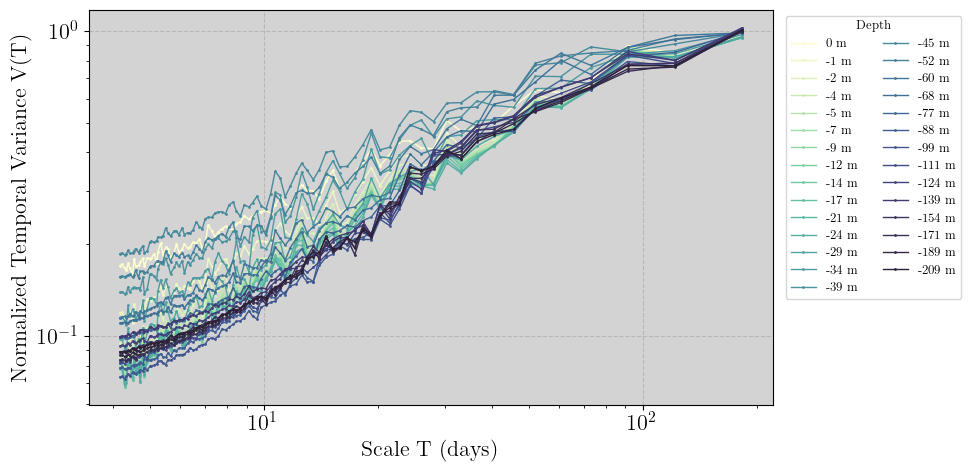

In [27]:
# Set plotting parameters
mooring_idx = 0 

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Set colormap from depths
cmap = cmo.deep
colors = [cmap(i / len(depth_upper)) for i in range(len(depth_upper))]

# Plot each depth
for i, idepth in enumerate(depth_upper):
    ax.plot(L_seg[mooring_idx,i,:]/24, V_seg[mooring_idx,i,:], '.-', label=f"{int(idepth)} m", color=colors[i], linewidth=1, markersize=2)

# Set legend
ax.legend(ncol=2,title="Depth", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9,title_fontsize=9)

# Set axis attributes
ax.set_xlabel(r"Scale T (days)")
ax.set_ylabel(r"Normalized Temporal Variance V(T)")
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, linestyle='--', alpha=0.8)

# Set the background color of the axes
ax.set_facecolor('lightgray')

# Display figure
plt.tight_layout()
plt.show()